# PCA on Correlation Matrices
In this notebook we apply PCA to the elements of the upper triangle (excluding the diagonal), reconstruct the matrices and measure reconstruction errors (MSE, MAE, Frobenius norm).

In [127]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', message='.*Clustering large matrix.*')

np.set_printoptions(suppress=True, precision=4)

## Step 1: Load Data
Load correlation matrices from one of the `corr_windows_tensor_data_*.pt` files and optionally select a matrix range `[MATRIX_START, MATRIX_END)`.

In [128]:
# Data path configuration
DATA_DIR = Path('../data/processed')
PT_FILE = DATA_DIR / 'corr_windows_tensor_data_00_20_w724_s10.pt'

if not PT_FILE.exists():
    raise FileNotFoundError(f'File not found: {PT_FILE.resolve()}')

# Select the matrix range to use: [MATRIX_START, MATRIX_END)
MATRIX_START = 49  # number or None
MATRIX_END = None  # number or None, Example: 500 to use only the first 500 matrices

print(f'File selected: {PT_FILE.name}')
print(f'Matrix range: [{MATRIX_START}, {MATRIX_END})')

File selected: corr_windows_tensor_data_00_20_w724_s10.pt
Matrix range: [49, None)


In [129]:
def load_corr_payload(pt_path: Path):
    payload = torch.load(pt_path, map_location='cpu')

    if isinstance(payload, dict):
        corr_tensor = payload.get('corr_tensor', None)
        meta = {k: v for k, v in payload.items() if k != 'corr_tensor'}
    elif isinstance(payload, torch.Tensor):
        corr_tensor = payload
        meta = {}
    else:
        raise TypeError(f'Unsupported .pt format: {type(payload)}')

    if corr_tensor is None:
        raise KeyError('corr_tensor key not found in .pt file')

    if corr_tensor.ndim != 3 or corr_tensor.shape[1] != corr_tensor.shape[2]:
        raise ValueError(f'Invalid shape for corr_tensor: {corr_tensor.shape}')

    return corr_tensor.float(), meta


corr_tensor, meta = load_corr_payload(PT_FILE)

orig_n = corr_tensor.shape[0]
start_idx = 0 if MATRIX_START is None else int(MATRIX_START)
end_idx = orig_n if MATRIX_END is None else int(MATRIX_END)

if not (0 <= start_idx < end_idx <= orig_n):
    raise ValueError(f'Invalid matrix range [{start_idx}, {end_idx}) for dataset size {orig_n}')

corr_tensor = corr_tensor[start_idx:end_idx]
if 'window_ranges' in meta and len(meta['window_ranges']) == orig_n:
    meta['window_ranges'] = meta['window_ranges'][start_idx:end_idx]

print(f'corr_tensor shape (selected range): {tuple(corr_tensor.shape)}')
print(f'using matrices: [{start_idx}, {end_idx}) out of {orig_n}')
print(f'dtype: {corr_tensor.dtype}')

corr_tensor shape (selected range): (412, 362, 362)
using matrices: [49, 461) out of 461
dtype: torch.float32


## Step 2: Prepare 2D Matrices for Intra-Matrix PCA
Use each correlation matrix directly as a 2D input (N x N).
For each matrix, PCA is fit along rows/features and reduced to N x K.

In [130]:
corr_np = corr_tensor.numpy()
n_matrices, n_assets, _ = corr_np.shape

print(f'Number of matrices: {n_matrices}')
print(f'Assets per matrix (N): {n_assets}')
print(f'Each input matrix shape: ({n_assets}, {n_assets})')

Number of matrices: 412
Assets per matrix (N): 362
Each input matrix shape: (362, 362)


## Step 3: Fit 2D-PCA (N x N -> N x K)
For every matrix:
- Input shape: N x N
- Reduced representation: N x K
- Reconstructed matrix (via inverse transform): N x N

In [131]:
def fit_2dpca(corr_mats: np.ndarray, n_components: int):
    if corr_mats.ndim != 3 or corr_mats.shape[1] != corr_mats.shape[2]:
        raise ValueError(f'Expected shape (n_samples, N, N), got {corr_mats.shape}')

    n_samples, n_assets, _ = corr_mats.shape
    if not (1 <= n_components <= n_assets):
        raise ValueError(f'n_components must be in [1, {n_assets}]')

    # 1) Mean matrix
    mean_mat = np.mean(corr_mats, axis=0)

    # 2) Scatter matrix
    diff = corr_mats - mean_mat
    scatter_matrix = np.mean(np.matmul(diff.transpose(0, 2, 1), diff), axis=0)

    # 3) Eigen-decomposition (scatter matrix is symmetric)
    eigenvalues, eigenvectors = np.linalg.eigh(scatter_matrix)
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues = eigenvalues[idx]
    eigenvectors = eigenvectors[:, idx]

    # 4) Projection matrix
    projection_matrix = eigenvectors[:, :n_components]

    # 5) Project and reconstruct
    projected_mats = np.matmul(corr_mats, projection_matrix)
    recon_mats = np.matmul(projected_mats, projection_matrix.T)

    # Keep correlation-matrix structure after reconstruction.
    #recon_mats = 0.5 * (recon_mats + np.transpose(recon_mats, (0, 2, 1)))
    #for i in range(n_samples):
    #    np.fill_diagonal(recon_mats[i], 1.0)

    explained_variance = eigenvalues[:n_components] / np.sum(eigenvalues)

    return {
        'projected': projected_mats,
        'recon_corr': recon_mats,
        'components': projection_matrix,
        'explained_variance': explained_variance
    }

In [132]:
N_COMPONENTS = 12
if N_COMPONENTS > n_assets:
    raise ValueError(f'N_COMPONENTS={N_COMPONENTS} is too large, max is {n_assets}')

pca_out = fit_2dpca(corr_np, n_components=N_COMPONENTS)

explained_ratio = pca_out['explained_variance']
var_percent = explained_ratio.sum() * 100
print('--- 2D-PCA Results ---')
print(f'Original tensor shape:         {corr_np.shape}')
print(f'Reduced tensor shape (N x K):  {pca_out["projected"].shape}')
print(f'Components extracted (K):      {N_COMPONENTS}')
print(f'Explained variance (top K):    {var_percent:.2f}%\n')
for idx, var in enumerate(explained_ratio):
    print(f'Variance PC{idx+1}: {(var * 100):.2f}%')

--- 2D-PCA Results ---
Original tensor shape:         (412, 362, 362)
Reduced tensor shape (N x K):  (412, 362, 12)
Components extracted (K):      12
Explained variance (top K):    93.84%

Variance PC1: 75.17%
Variance PC2: 7.27%
Variance PC3: 2.91%
Variance PC4: 1.99%
Variance PC5: 1.58%
Variance PC6: 1.32%
Variance PC7: 1.03%
Variance PC8: 0.81%
Variance PC9: 0.58%
Variance PC10: 0.46%
Variance PC11: 0.39%
Variance PC12: 0.31%


## Step 4: Reconstruct Correlation Matrices
Reconstruct each matrix from its N x K representation using inverse transform.
Then enforce symmetry and set the diagonal to 1.0 to keep correlation-matrix structure.

In [133]:
orig_corr = corr_np
recon_corr = pca_out['recon_corr']
reduced_corr = pca_out['projected']

print(f'orig_corr shape: {orig_corr.shape}')
print(f'reduced_corr shape (N x K): {reduced_corr.shape}')
print(f'recon_corr shape: {recon_corr.shape}')

orig_corr shape: (412, 362, 362)
reduced_corr shape (N x K): (412, 362, 12)
recon_corr shape: (412, 362, 362)


## Step 5: Matrix-Level Reconstruction Visualization
Visualize one reconstructed matrix with:
- Hierarchical clustering heatmaps (original, reconstructed, error)
- Standard heatmaps without clustering (original order preserved)

Original Matrix:
[[1.     0.3999 0.3217 0.3456 0.4316]
 [0.3999 1.     0.3521 0.4409 0.4306]
 [0.3217 0.3521 1.     0.3798 0.382 ]
 [0.3456 0.4409 0.3798 1.     0.3974]
 [0.4316 0.4306 0.382  0.3974 1.    ]]
Reconstructed Matrix:
[[0.4472 0.3827 0.3651 0.3667 0.4139]
 [0.3929 0.4823 0.3386 0.336  0.4373]
 [0.3779 0.3768 0.3362 0.309  0.3904]
 [0.4304 0.4586 0.3007 0.4829 0.4332]
 [0.4506 0.4204 0.3848 0.3546 0.4716]]
Error Matrix:
[[-0.5528 -0.0172  0.0434  0.0211 -0.0177]
 [-0.0069 -0.5177 -0.0136 -0.105   0.0067]
 [ 0.0563  0.0246 -0.6638 -0.0708  0.0084]
 [ 0.0848  0.0177 -0.0791 -0.5171  0.0357]
 [ 0.019  -0.0102  0.0028 -0.0428 -0.5284]]
Sample index: 200
MSE: 0.002113 | MAE: 0.031414 | Frobenius: 16.640249
Error range - Min: -0.824399 | Max: 0.193206


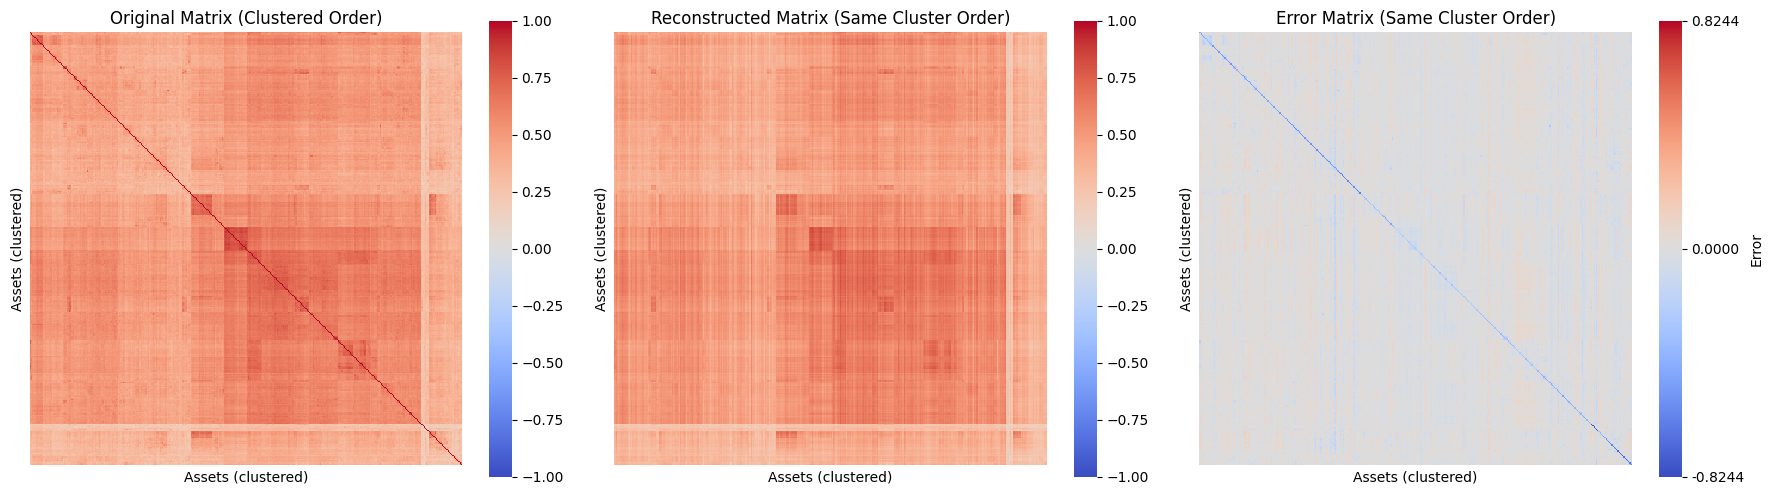

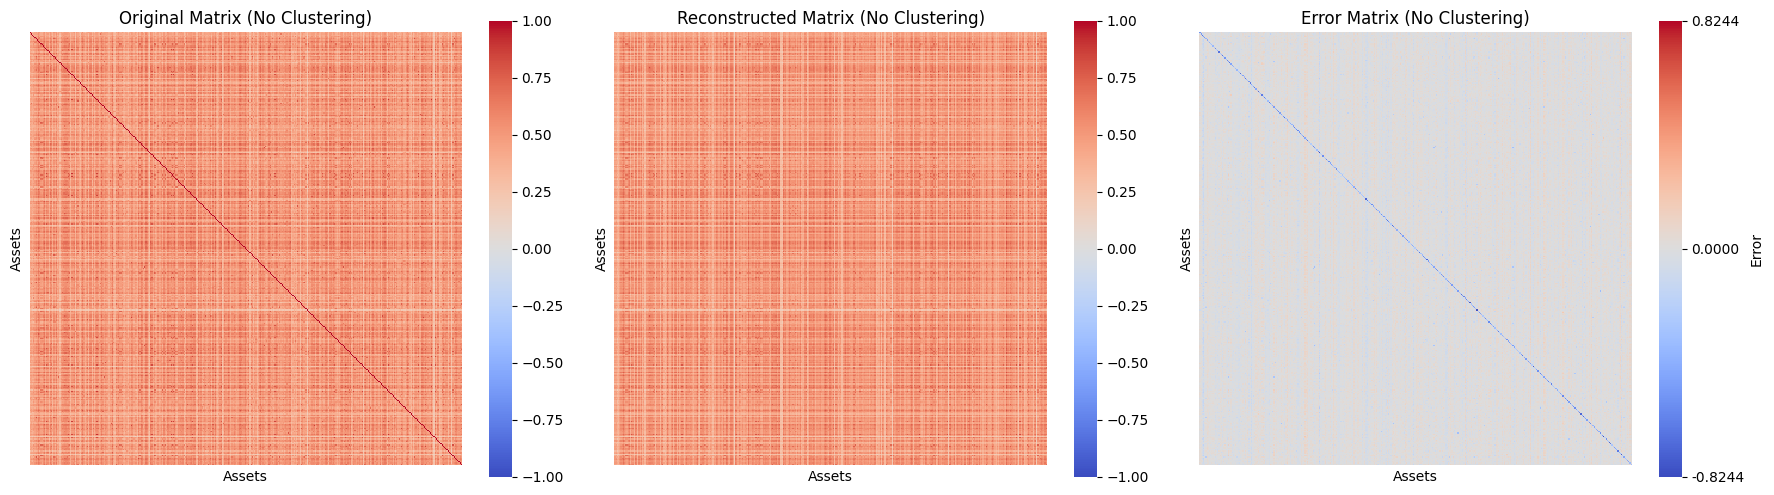

In [134]:
SAMPLE_IDX = 200





if not (0 <= SAMPLE_IDX < corr_np.shape[0]):
    raise ValueError(f'SAMPLE_IDX must be in [0, {corr_np.shape[0] - 1}]')

orig_mat = corr_np[SAMPLE_IDX]
recon_mat = recon_corr[SAMPLE_IDX]
err_mat = recon_mat - orig_mat

print(f"Original Matrix:\n{orig_mat[:5, :5]}")  # Print the top-left 5x5 block of the original matrix for inspection
print(f"Reconstructed Matrix:\n{recon_mat[:5, :5]}")  # Print the top-left 5x5 block of the reconstructed matrix for inspection
print(f"Error Matrix:\n{err_mat[:5, :5]}")  # Print the top-left 5x5 block of the error matrix for inspection

mse_sample = float(np.mean((recon_mat - orig_mat) ** 2))
mae_sample = float(np.mean(np.abs(recon_mat - orig_mat)))
fro_sample = float(np.linalg.norm(recon_mat - orig_mat, ord='fro'))

print(f'Sample index: {SAMPLE_IDX}')
print(f'MSE: {mse_sample:.6f} | MAE: {mae_sample:.6f} | Frobenius: {fro_sample:.6f}')
print(f'Error range - Min: {err_mat.min():.6f} | Max: {err_mat.max():.6f}')

# Use the same colormap for all matrices.
shared_cmap = 'coolwarm'

# Error scale must be symmetric around zero: [-max|err|, +max|err|]
err_abs_max = float(np.max(np.abs(err_mat)))
if err_abs_max == 0:
    err_abs_max = 1e-6

# Build a single cluster ordering from the original matrix and reuse it for all three panels.
cluster_ref = sns.clustermap(
    orig_mat,
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    linewidths=0,
    figsize=(8, 8),
    cbar_kws={'label': 'Correlation'},
)
row_order = cluster_ref.dendrogram_row.reordered_ind
col_order = cluster_ref.dendrogram_col.reordered_ind
plt.close(cluster_ref.fig)

orig_mat_clustered = orig_mat[np.ix_(row_order, col_order)]
recon_mat_clustered = recon_mat[np.ix_(row_order, col_order)]
err_mat_clustered = err_mat[np.ix_(row_order, col_order)]

# Clustered heatmaps in a single side-by-side figure (without dendrograms).
fig_cluster, axes_cluster = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    orig_mat_clustered,
    ax=axes_cluster[0],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[0].set_title('Original Matrix (Clustered Order)')

sns.heatmap(
    recon_mat_clustered,
    ax=axes_cluster[1],
    vmin=-1,
    vmax=1,
    cmap=shared_cmap,
    square=True,
 )
axes_cluster[1].set_title('Reconstructed Matrix (Same Cluster Order)')

hm_cluster_err = sns.heatmap(
    err_mat_clustered,
    ax=axes_cluster[2],
    vmin=-err_abs_max,
    vmax=err_abs_max,
    cmap=shared_cmap,
    center=0,
    square=True,
    cbar_kws={'label': 'Error'},
)
axes_cluster[2].set_title('Error Matrix (Same Cluster Order)')

cbar_cluster = hm_cluster_err.collections[0].colorbar
cbar_cluster.set_ticks([-err_abs_max, 0, err_abs_max])
cbar_cluster.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes_cluster:
    ax.set_xlabel('Assets (clustered)')
    ax.set_ylabel('Assets (clustered)')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

# Standard heatmaps (no clustering, original matrix order)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(orig_mat, ax=axes[0], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[0].set_title('Original Matrix (No Clustering)')

sns.heatmap(recon_mat, ax=axes[1], vmin=-1, vmax=1, cmap=shared_cmap, square=True)
axes[1].set_title('Reconstructed Matrix (No Clustering)')

hm = sns.heatmap(err_mat, ax=axes[2], vmin=-err_abs_max, vmax=err_abs_max, cmap=shared_cmap, center=0, square=True, cbar_kws={'label': 'Error'})
axes[2].set_title('Error Matrix (No Clustering)')
# Set colorbar ticks for standard heatmap
cbar = hm.collections[0].colorbar
cbar.set_ticks([-err_abs_max, 0, err_abs_max])
cbar.set_ticklabels([f'{-err_abs_max:.4f}', '0.0000', f'{err_abs_max:.4f}'])

for ax in axes:
    ax.set_xlabel('Assets')
    ax.set_ylabel('Assets')
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## Step 6: Calculate Reconstruction Errors
Measure reconstruction quality using three metrics:
- **MSE**: Mean Squared Error
- **MAE**: Mean Absolute Error  
- **Frobenius**: Frobenius norm of the difference

In [135]:
def reconstruction_errors(original: np.ndarray, reconstructed: np.ndarray):
    diff = original - reconstructed

    mse_per_matrix = np.mean(diff ** 2, axis=(1, 2))
    mae_per_matrix = np.mean(np.abs(diff), axis=(1, 2))
    fro_per_matrix = np.linalg.norm(diff, ord='fro', axis=(1, 2))

    summary = pd.DataFrame({
        'MSE': mse_per_matrix,
        'MAE': mae_per_matrix,
        'Frobenius': fro_per_matrix
    })

    stats = summary.agg(['mean', 'std', 'min', 'median', 'max']).T
    return summary, stats




errors_df, errors_stats = reconstruction_errors(orig_corr, recon_corr)

print('Reconstruction error statistics:')
display(errors_stats)

Reconstruction error statistics:


,mean,std,min,median,max
MSE,0.003046,0.000581,0.002081,0.003000,0.004033
MAE,0.037379,0.003131,0.031130,0.037703,0.042648
Frobenius,19.888172,1.916029,16.511919,19.828554,22.989418


## Step 7: Error Analysis Across Components
Sweep over different numbers of PCA components and track how reconstruction errors decrease as we add more components.

In [136]:
# Error evaluation varying number of components
candidate_components = [1, 2, 3, 5, 10, 12, 20, 30, 40, 50, 100, 200, 362]
candidate_components = [c for c in candidate_components if c <= n_assets]
print(f'Evaluating PCA reconstruction errors for components: {candidate_components}')
rows = []
for n_comp in candidate_components:
    out = fit_2dpca(orig_corr, n_comp)
    recon = out['recon_corr']
    _, stats = reconstruction_errors(orig_corr, recon)

    rows.append({
        'n_components': n_comp,
        'cumulative_explained_variance': float(out['explained_variance'].sum()),
        'MSE_mean': float(stats.loc['MSE', 'mean']),
        'MAE_mean': float(stats.loc['MAE', 'mean']),
        'Frobenius_mean': float(stats.loc['Frobenius', 'mean'])
    })

sweep_df = pd.DataFrame(rows)
display(sweep_df)

Evaluating PCA reconstruction errors for components: [1, 2, 3, 5, 10, 12, 20, 30, 40, 50, 100, 200, 362]


,n_components,cumulative_explained_variance,MSE_mean,MAE_mean,Frobenius_mean
0,1,0.751728,1.138034e-02,7.670908e-02,38.046101
1,2,0.824467,8.258487e-03,6.540576e-02,32.692165
2,3,0.853568,7.549825e-03,6.234375e-02,31.260296
3,5,0.889293,4.873893e-03,4.853267e-02,25.139473
4,10,0.931423,3.447164e-03,4.017479e-02,21.155178
5,12,0.938378,3.046317e-03,3.737886e-02,19.888172
6,20,0.954066,1.947721e-03,2.838188e-02,15.898615
7,30,0.962529,1.480756e-03,2.384305e-02,13.835973
8,40,0.967513,1.277904e-03,2.207585e-02,12.847484
9,50,0.971088,1.143017e-03,2.093186e-02,12.143797


## Step 8: Visualize Results
Generate plots showing:
1. **Cumulative explained variance**: How much information is captured as components increase
2. **Reconstruction errors**: MSE, MAE, and Frobenius norm vs. number of components

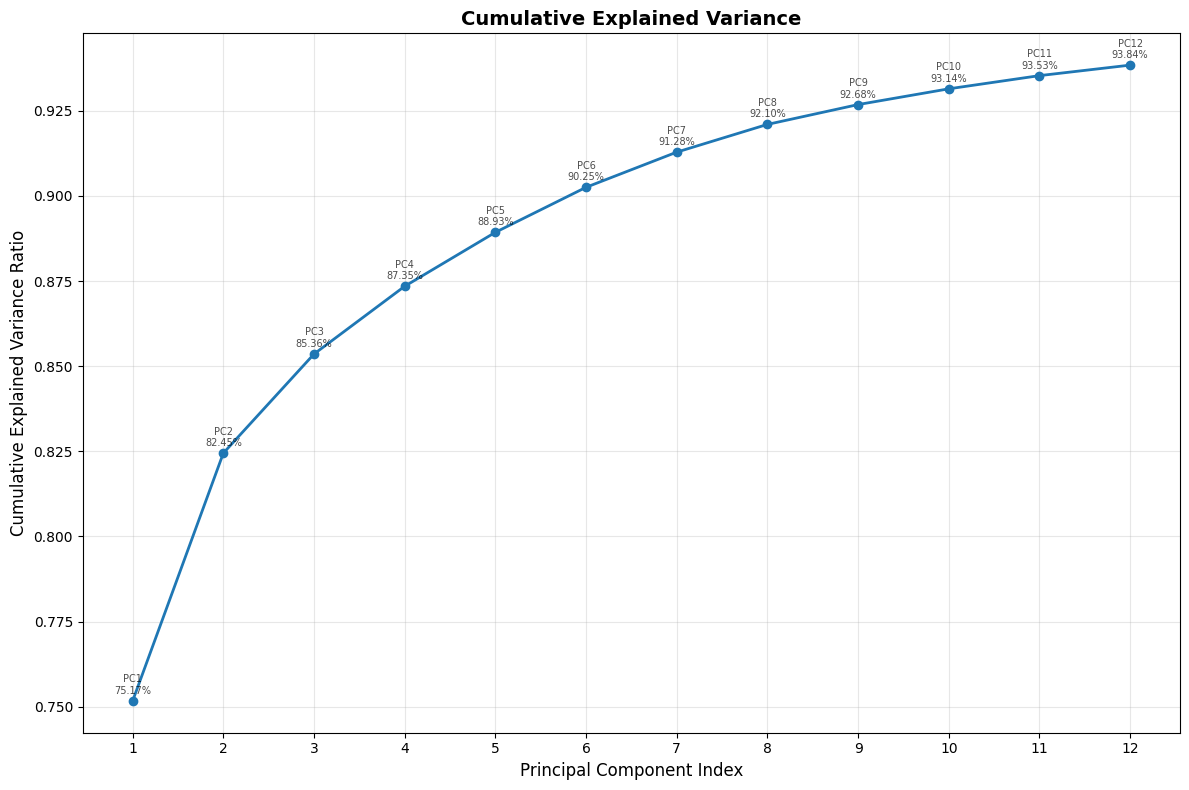

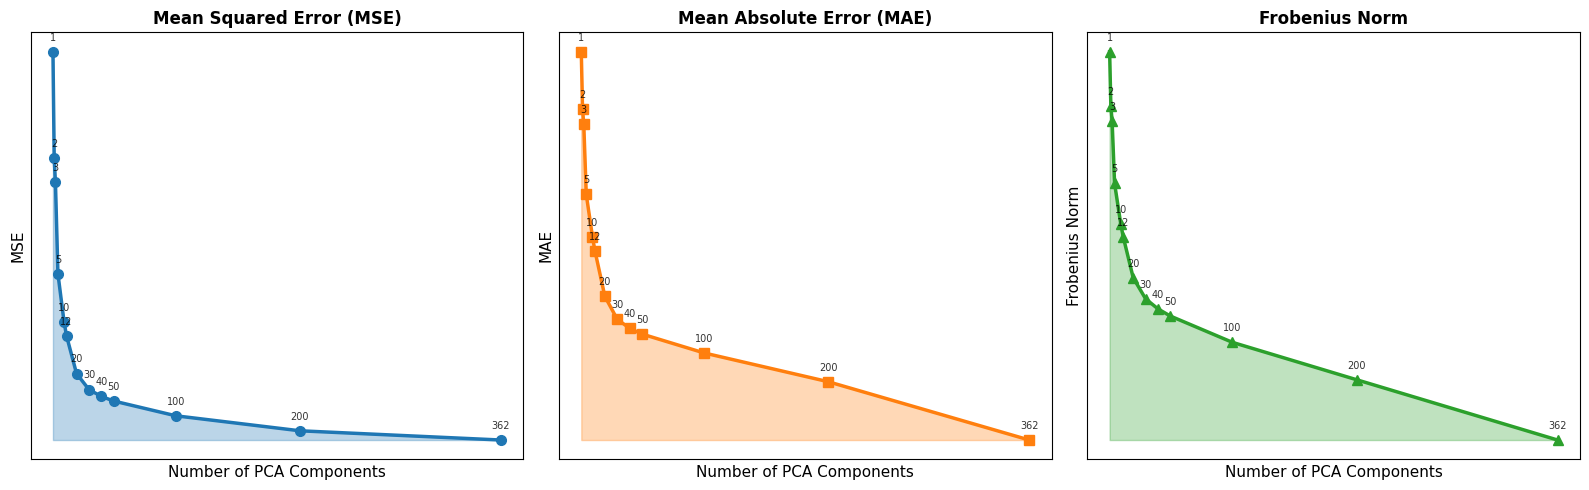

In [137]:
# Plot 1: Cumulative Explained Variance
fig1, ax1 = plt.subplots(figsize=(12, 8))

cum_var = np.cumsum(pca_out['explained_variance'])
ax1.plot(np.arange(1, len(cum_var) + 1), cum_var, marker='o', linewidth=2, markersize=6)

# Add annotations with cumulative variance values at each marker
for i, val in enumerate(cum_var):
    ax1.annotate(f'PC{i+1}\n{val*100:.2f}%', 
                 xy=(i+1, val), 
                 xytext=(0, 5), 
                 textcoords='offset points',
                 ha='center',
                 fontsize=7,
                 alpha=0.7)

ax1.set_title('Cumulative Explained Variance', fontsize=14, fontweight='bold')
ax1.set_xlabel('Principal Component Index', fontsize=12)
ax1.set_ylabel('Cumulative Explained Variance Ratio', fontsize=12)
ax1.set_xticks((np.arange(1, len(cum_var) + 1)))
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Reconstruction Errors with separate subplots for each metric
fig2, axes = plt.subplots(1, 3, figsize=(16, 5))

# MSE subplot
axes[0].plot(sweep_df['n_components'], sweep_df['MSE_mean'], marker='o', linewidth=2.5, markersize=7, color='#1f77b4')
axes[0].fill_between(sweep_df['n_components'], sweep_df['MSE_mean'], alpha=0.3, color='#1f77b4')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MSE_mean'])):
    axes[0].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[0].set_title('Mean Squared Error (MSE)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Number of PCA Components', fontsize=11)
axes[0].set_ylabel('MSE', fontsize=11)
axes[0].grid(True, alpha=0.3)

# MAE subplot
axes[1].plot(sweep_df['n_components'], sweep_df['MAE_mean'], marker='s', linewidth=2.5, markersize=7, color='#ff7f0e')
axes[1].fill_between(sweep_df['n_components'], sweep_df['MAE_mean'], alpha=0.3, color='#ff7f0e')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['MAE_mean'])):
    axes[1].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[1].set_title('Mean Absolute Error (MAE)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of PCA Components', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].grid(True, alpha=0.3)

# Frobenius norm subplot
axes[2].plot(sweep_df['n_components'], sweep_df['Frobenius_mean'], marker='^', linewidth=2.5, markersize=7, color='#2ca02c')
axes[2].fill_between(sweep_df['n_components'], sweep_df['Frobenius_mean'], alpha=0.3, color='#2ca02c')
for i, (n_comp, val) in enumerate(zip(sweep_df['n_components'], sweep_df['Frobenius_mean'])):
    axes[2].annotate(f'{int(n_comp)}', xy=(n_comp, val), xytext=(0, 8), textcoords='offset points', 
                     ha='center', fontsize=7, alpha=0.8)
axes[2].set_title('Frobenius Norm', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Number of PCA Components', fontsize=11)
axes[2].set_ylabel('Frobenius Norm', fontsize=11)
axes[2].grid(True, alpha=0.3)

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()